# Visualización de Almacenes con Peatones

Carga `warehouse_mapXX.json` (layout) y los ficheros `.wbt` con peatones y genera:
- Tabla resumen con dimensiones, estanterías y número de peatones
- Vista cenital con estanterías, goals, WAITING, DROPOFF y trayectorias de peatones

> **Nota WH01**: Tiene dos variantes con peatón (`warehouse_1_1ped.wbt` para STHWP y `warehouse_1_subwp_1ped.wbt` para SUBWP), ambas con 1 peatón. Los almacenes WH02–WH05 usan `warehouse_ped_XX.wbt`.

In [1]:
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import pandas as pd

MAP_DIR = Path('../simulacion/controllers/rl_train_STHWP')
WBT_DIR = Path('../simulacion/worlds')
OUT_DIR = Path('imagenes')
OUT_DIR.mkdir(exist_ok=True)

SHELF_L = 1.9
SHELF_W = 0.8

# Almacenes estándar (map_id → wbt filename)
STANDARD = {
    2: 'warehouse_ped_02.wbt',
    3: 'warehouse_ped_03.wbt',
    4: 'warehouse_ped_04.wbt',
    5: 'warehouse_ped_05.wbt',
}

# WH01: dos variantes con nombres distintos
WH01_VARIANTS = [
    {'label': 'WH01_STHWP', 'map_id': 1, 'wbt': 'warehouse_1_1ped.wbt'},
    {'label': 'WH01_SUBWP', 'map_id': 1, 'wbt': 'warehouse_1_subwp_1ped.wbt'},
]

def load_map(wh_id):
    p = MAP_DIR / f'warehouse_map{wh_id:02d}.json'
    with open(p) as f:
        return json.load(f)

def parse_pedestrians(wbt_filename):
    """Extrae trayectorias y posición inicial de cada peatón del .wbt."""
    text = (WBT_DIR / wbt_filename).read_text()
    peds = []
    blocks = re.findall(
        r'DEF (PEDESTRIAN_\d+) Pedestrian \{(.*?)\}\n',
        text, re.DOTALL
    )
    for name, body in blocks:
        m_trans = re.search(r'translation\s+([\-\d.]+)\s+([\-\d.]+)', body)
        m_traj  = re.search(r'--trajectory=([\-\d.,\s]+)', body)
        m_speed = re.search(r'--speed=([\d.]+)', body)
        if not (m_trans and m_traj):
            continue
        px = float(m_trans.group(1))
        py = float(m_trans.group(2))
        speed = float(m_speed.group(1)) if m_speed else 0.5
        waypoints = []
        for pt in m_traj.group(1).strip().split(','):
            coords = pt.strip().split()
            if len(coords) >= 2:
                waypoints.append((float(coords[0]), float(coords[1])))
        peds.append({'name': name, 'x': px, 'y': py,
                     'speed': speed, 'waypoints': waypoints})
    return peds

# Cargar todos
entries = []  # lista de dicts {label, map_id, wbt, data, ped_list}
for v in WH01_VARIANTS:
    entries.append({**v, 'data': load_map(v['map_id']),
                    'ped_list': parse_pedestrians(v['wbt'])})
for map_id, wbt in STANDARD.items():
    label = f'WH{map_id:02d}'
    entries.append({'label': label, 'map_id': map_id, 'wbt': wbt,
                    'data': load_map(map_id),
                    'ped_list': parse_pedestrians(wbt)})

for e in entries:
    print(f"{e['label']:15s}: {len(e['data']['shelves'])} estanterías, "
          f"{len(e['ped_list'])} peatones  [{e['wbt']}]")

WH01_STHWP     : 28 estanterías, 1 peatones  [warehouse_1_1ped.wbt]
WH01_SUBWP     : 28 estanterías, 1 peatones  [warehouse_1_subwp_1ped.wbt]
WH02           : 172 estanterías, 1 peatones  [warehouse_ped_02.wbt]
WH03           : 96 estanterías, 1 peatones  [warehouse_ped_03.wbt]
WH04           : 596 estanterías, 1 peatones  [warehouse_ped_04.wbt]
WH05           : 492 estanterías, 1 peatones  [warehouse_ped_05.wbt]


## Tabla resumen

In [2]:
rows = []
for e in entries:
    d   = e['data']
    ps  = e['ped_list']
    m   = d['map']
    res = m['resolution']
    W   = m['width']  * res
    L   = m['height'] * res
    zones = d['zones']
    traj_lens = []
    for p in ps:
        wp = p['waypoints']
        if len(wp) >= 2:
            dx = wp[1][0] - wp[0][0]
            dy = wp[1][1] - wp[0][1]
            traj_lens.append(round((dx**2 + dy**2)**0.5, 1))
    rows.append({
        'Almacén':              e['label'],
        'WBT':                  e['wbt'],
        'Ancho (m)':            W,
        'Largo (m)':            L,
        'Nº estanterías':       len(d['shelves']),
        'Nº peatones':          len(ps),
        'Vel. (m/s)':           ps[0]['speed'] if ps else '-',
        'Long. tray. (m)':      f'{min(traj_lens)}–{max(traj_lens)}' if traj_lens else '-',
        'WAITING':              f"({zones['waiting']['x']}, {zones['waiting']['y']})",
        'DROPOFF':              f"({zones['dropoff']['x']}, {zones['dropoff']['y']})",
    })

df = pd.DataFrame(rows).set_index('Almacén')
df

,WBT,Ancho (m),Largo (m),Nº estanterías,Nº peatones,Vel. (m/s),Long. tray. (m),WAITING,DROPOFF
Almacén,,,,,,,,,
WH01_STHWP,warehouse_1_1ped.wbt,23.00,22.0,28,1,0.5,8.0–8.0,"(-6.6, -8.5)","(-11.0, 0.0)"
WH01_SUBWP,warehouse_1_subwp_1ped.wbt,23.00,22.0,28,1,0.5,8.0–8.0,"(-6.6, -8.5)","(-11.0, 0.0)"
WH02,warehouse_ped_02.wbt,35.00,38.0,172,1,0.5,26.6–26.6,"(0.0, -17.5)","(0.0, 16.5)"
WH03,warehouse_ped_03.wbt,28.00,36.0,96,1,0.5,8.6–8.6,"(-12.5, -16.5)","(-12.5, 16.5)"
WH04,warehouse_ped_04.wbt,59.25,70.0,596,1,0.5,57.0–57.0,"(0.0, -33.0)","(0.0, 33.0)"
WH05,warehouse_ped_05.wbt,70.00,100.0,492,1,0.5,86.0–86.0,"(-32.0, -44.0)","(0.0, 48.0)"


## Vista cenital por almacén (con trayectorias de peatones)

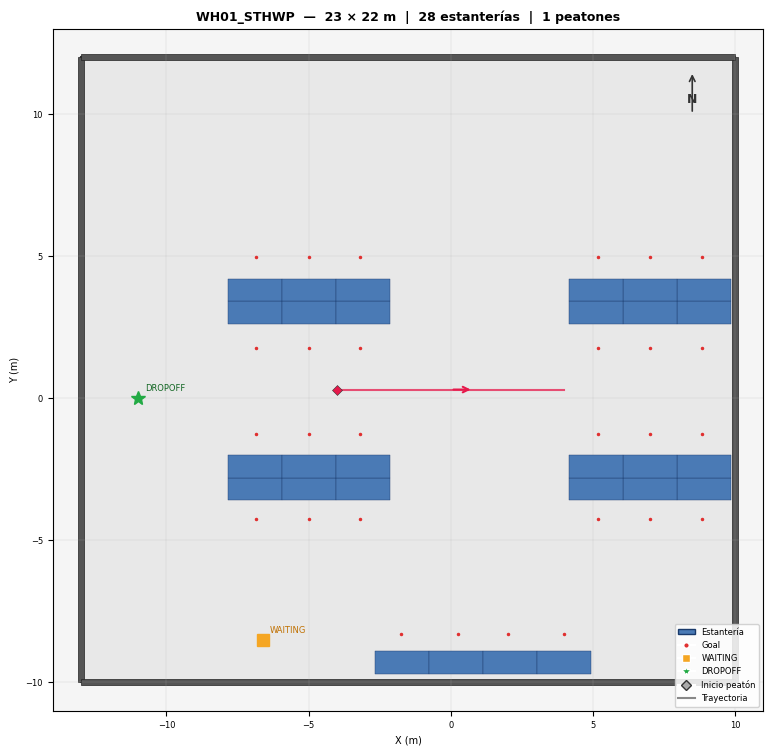

  → imagenes/warehouse_ped_WH01_STHWP.png


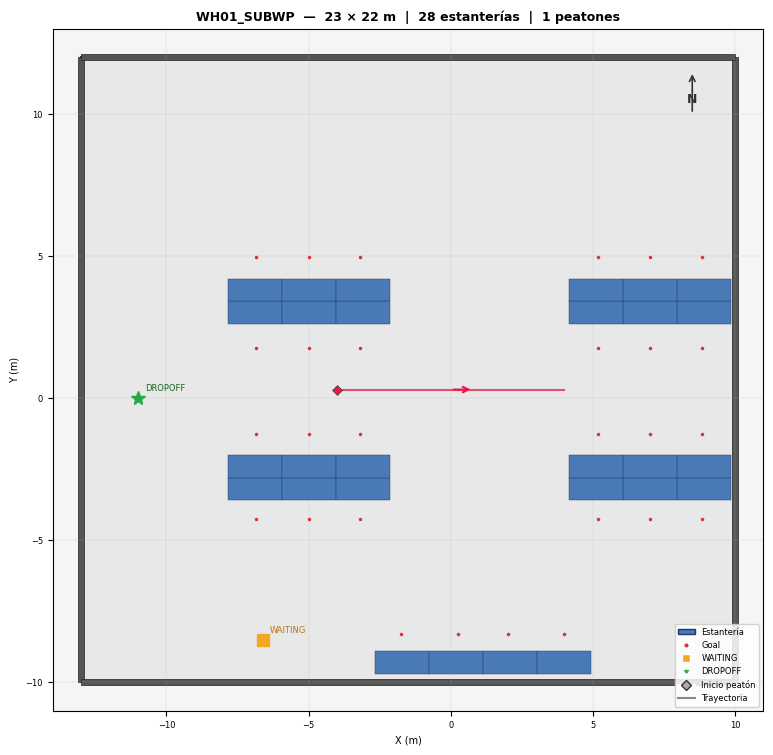

  → imagenes/warehouse_ped_WH01_SUBWP.png


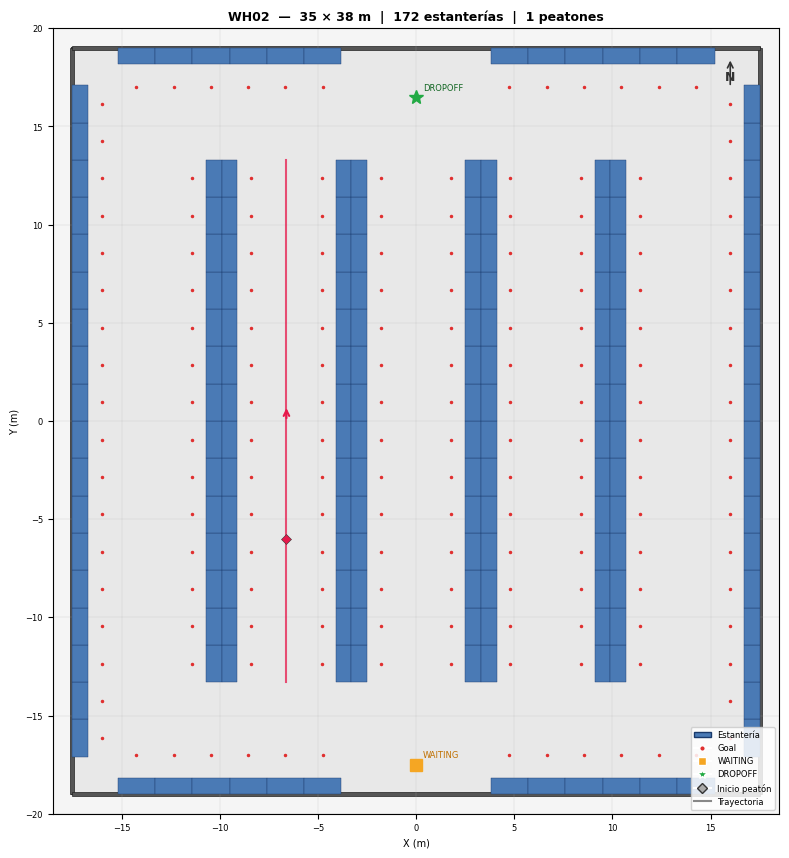

  → imagenes/warehouse_ped_WH02.png


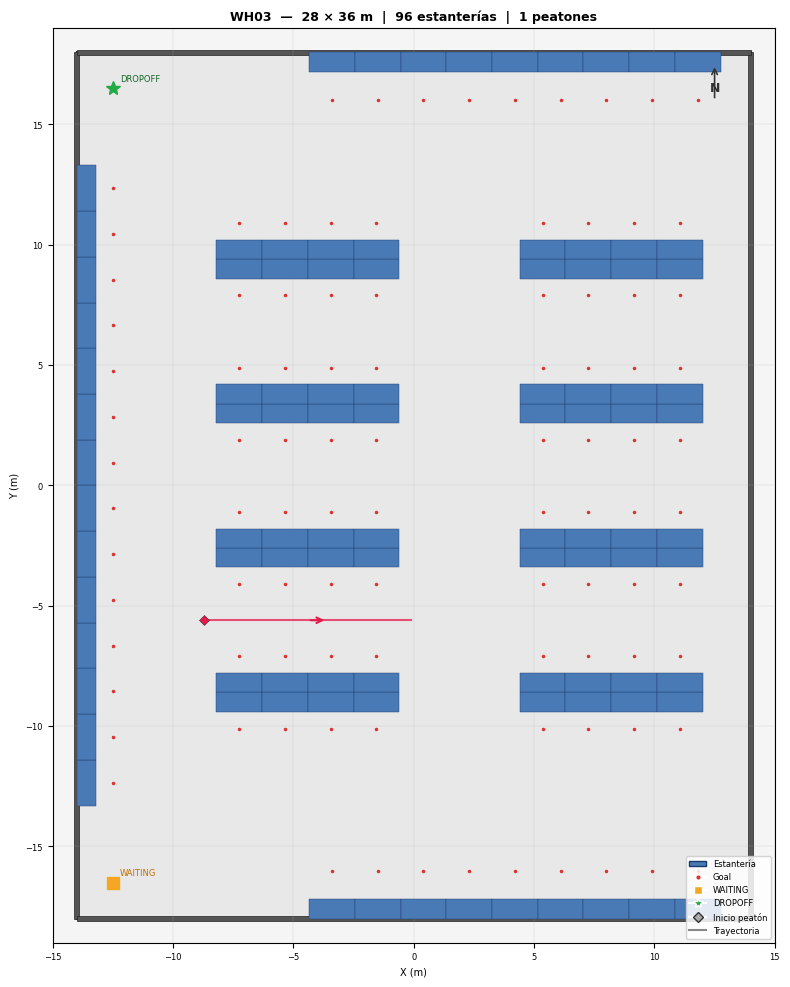

  → imagenes/warehouse_ped_WH03.png


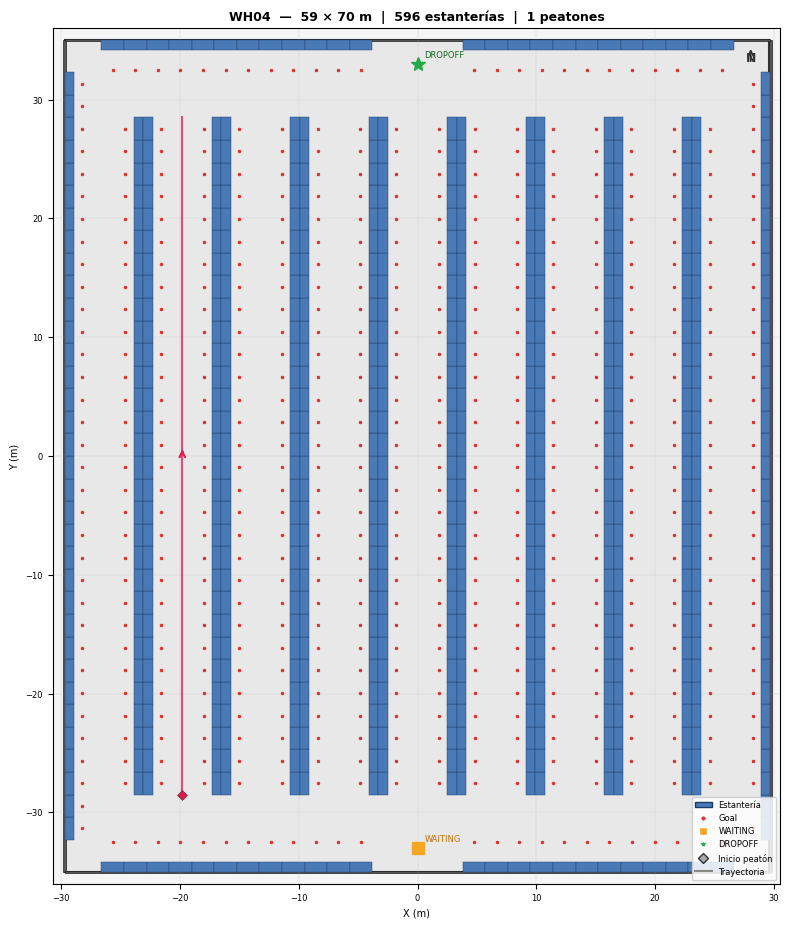

  → imagenes/warehouse_ped_WH04.png


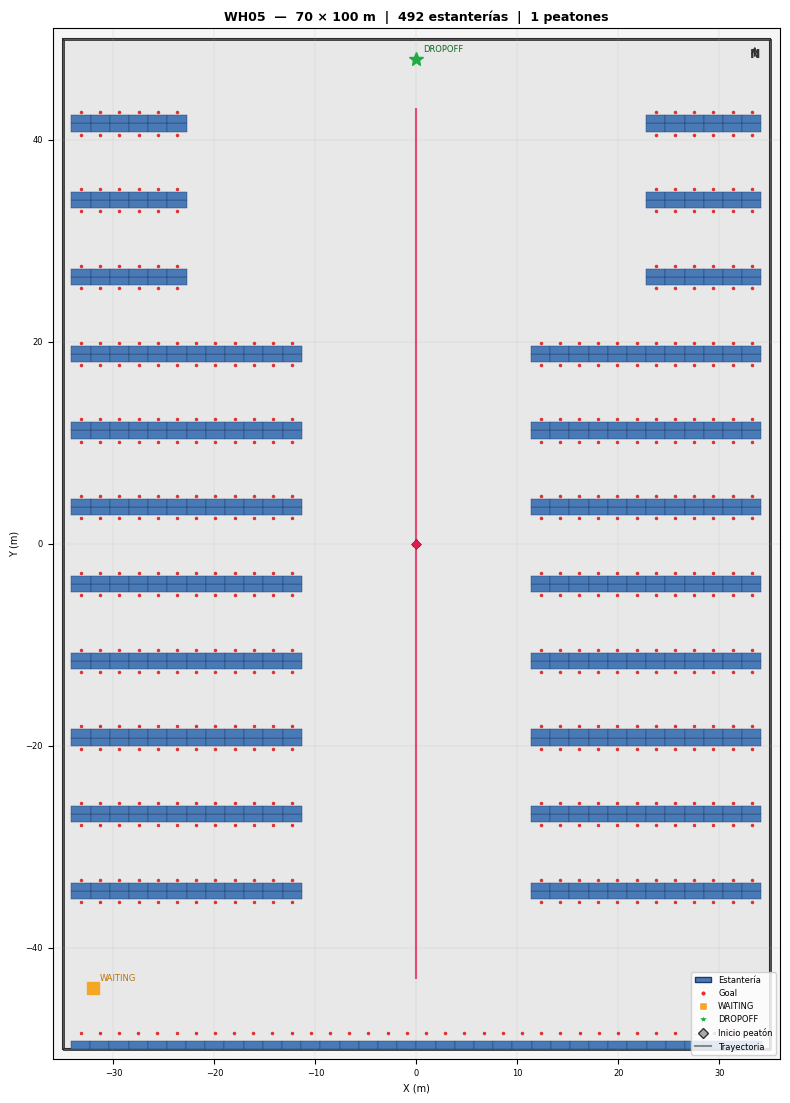

  → imagenes/warehouse_ped_WH05.png


In [3]:
PED_COLORS = [
    '#e6194b','#f58231','#ffe119','#3cb44b','#42d4f4',
    '#4363d8','#911eb4','#f032e6','#a9a9a9','#800000',
]

def guess_rot90(s):
    return abs(s['goal_y'] - s['shelf_y']) > abs(s['goal_x'] - s['shelf_x'])

def shelf_rect(sx, sy, rot90=False):
    w, h = (SHELF_L, SHELF_W) if rot90 else (SHELF_W, SHELF_L)
    return sx - w/2, sy - h/2, w, h

def plot_warehouse_ped(label, data, ped_list, ax):
    m      = data['map']
    res    = m['resolution']
    W      = m['width']  * res
    L      = m['height'] * res
    ox, oy = m['origin']
    xmin, xmax = ox, ox + W
    ymin, ymax = oy, oy + L
    shelves = data['shelves']
    zones   = data['zones']
    walls   = data.get('walls', [])

    ax.set_facecolor('#f5f5f5')
    ax.set_aspect('equal')
    ax.set_xlim(xmin - 1, xmax + 1)
    ax.set_ylim(ymin - 1, ymax + 1)

    ax.add_patch(mpatches.Rectangle(
        (xmin, ymin), W, L,
        linewidth=1.5, edgecolor='#333', facecolor='#e8e8e8', zorder=0))

    for wall in walls:
        wx, wy = wall['x'], wall['y']
        ww, wh = wall['w'], wall['h']
        ax.add_patch(mpatches.Rectangle(
            (wx - ww/2, wy - wh/2), ww, wh,
            facecolor='#555', edgecolor='#222', linewidth=0.5, zorder=1))

    for s in shelves:
        rot = guess_rot90(s)
        rx, ry, rw, rh = shelf_rect(s['shelf_x'], s['shelf_y'], rot)
        ax.add_patch(mpatches.Rectangle(
            (rx, ry), rw, rh,
            facecolor='#4a7ab5', edgecolor='#1a3a6b', linewidth=0.3, zorder=2))
        ax.plot(s['goal_x'], s['goal_y'], 'o',
                color='#e03030', markersize=1.5, zorder=3)

    for idx, p in enumerate(ped_list):
        color = PED_COLORS[idx % len(PED_COLORS)]
        wp = p['waypoints']
        if len(wp) >= 2:
            xs = [w[0] for w in wp]
            ys = [w[1] for w in wp]
            ax.plot(xs, ys, '-', color=color, linewidth=1.5, alpha=0.75, zorder=4)
            mx = (xs[0] + xs[1]) / 2
            my = (ys[0] + ys[1]) / 2
            dx = xs[1] - xs[0]
            dy = ys[1] - ys[0]
            norm = (dx**2 + dy**2)**0.5
            if norm > 0:
                ax.annotate('', xy=(mx + dx/norm*0.8, my + dy/norm*0.8),
                            xytext=(mx, my),
                            arrowprops=dict(arrowstyle='->', color=color, lw=1.5))
        ax.plot(p['x'], p['y'], 'D', color=color, markersize=5, zorder=5,
                markeredgecolor='#333', markeredgewidth=0.4)

    wx_w, wy_w = zones['waiting']['x'], zones['waiting']['y']
    ax.plot(wx_w, wy_w, 's', color='#f5a623', markersize=8, zorder=6)
    ax.annotate('WAITING', (wx_w, wy_w), xytext=(5, 5),
                textcoords='offset points', fontsize=6, color='#c07000')

    dx_d, dy_d = zones['dropoff']['x'], zones['dropoff']['y']
    ax.plot(dx_d, dy_d, '*', color='#22aa44', markersize=10, zorder=6)
    ax.annotate('DROPOFF', (dx_d, dy_d), xytext=(5, 5),
                textcoords='offset points', fontsize=6, color='#116622')

    ax.annotate('N', xy=(xmax - 1.5, ymax - 1.5), fontsize=9,
                fontweight='bold', ha='center', va='center', color='#333')
    ax.annotate('', xy=(xmax - 1.5, ymax - 0.5),
                xytext=(xmax - 1.5, ymax - 2.0),
                arrowprops=dict(arrowstyle='->', color='#333', lw=1.2))

    ax.set_title(
        f'{label}  —  {W:.0f} × {L:.0f} m  |  '
        f'{len(shelves)} estanterías  |  {len(ped_list)} peatones',
        fontsize=9, fontweight='bold')
    ax.set_xlabel('X (m)', fontsize=7)
    ax.set_ylabel('Y (m)', fontsize=7)
    ax.tick_params(labelsize=6)
    ax.grid(True, linewidth=0.3, alpha=0.5)

    legend_elements = [
        mpatches.Patch(facecolor='#4a7ab5', edgecolor='#1a3a6b', label='Estantería'),
        Line2D([0],[0], marker='o', color='w', markerfacecolor='#e03030',
               markersize=4, label='Goal'),
        Line2D([0],[0], marker='s', color='w', markerfacecolor='#f5a623',
               markersize=6, label='WAITING'),
        Line2D([0],[0], marker='*', color='w', markerfacecolor='#22aa44',
               markersize=8, label='DROPOFF'),
        Line2D([0],[0], marker='D', color='w', markerfacecolor='#aaa',
               markeredgecolor='#333', markersize=5, label='Inicio peatón'),
        Line2D([0],[0], color='#888', linewidth=1.5, label='Trayectoria'),
    ]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=6, framealpha=0.85)

# ── Figuras individuales ───────────────────────────────────────────────────────
for e in entries:
    data     = e['data']
    ped_list = e['ped_list']
    m   = data['map']
    res = m['resolution']
    W   = m['width']  * res
    L   = m['height'] * res
    fig_w = 8
    fig_h = max(5, min(14, fig_w * L / W))

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    plot_warehouse_ped(e['label'], data, ped_list, ax)
    plt.tight_layout()
    safe_label = e['label'].replace('/', '_')
    out_path = OUT_DIR / f'warehouse_ped_{safe_label}.png'
    fig.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  → {out_path}')

## Vista conjunta (todos los almacenes con peatones)

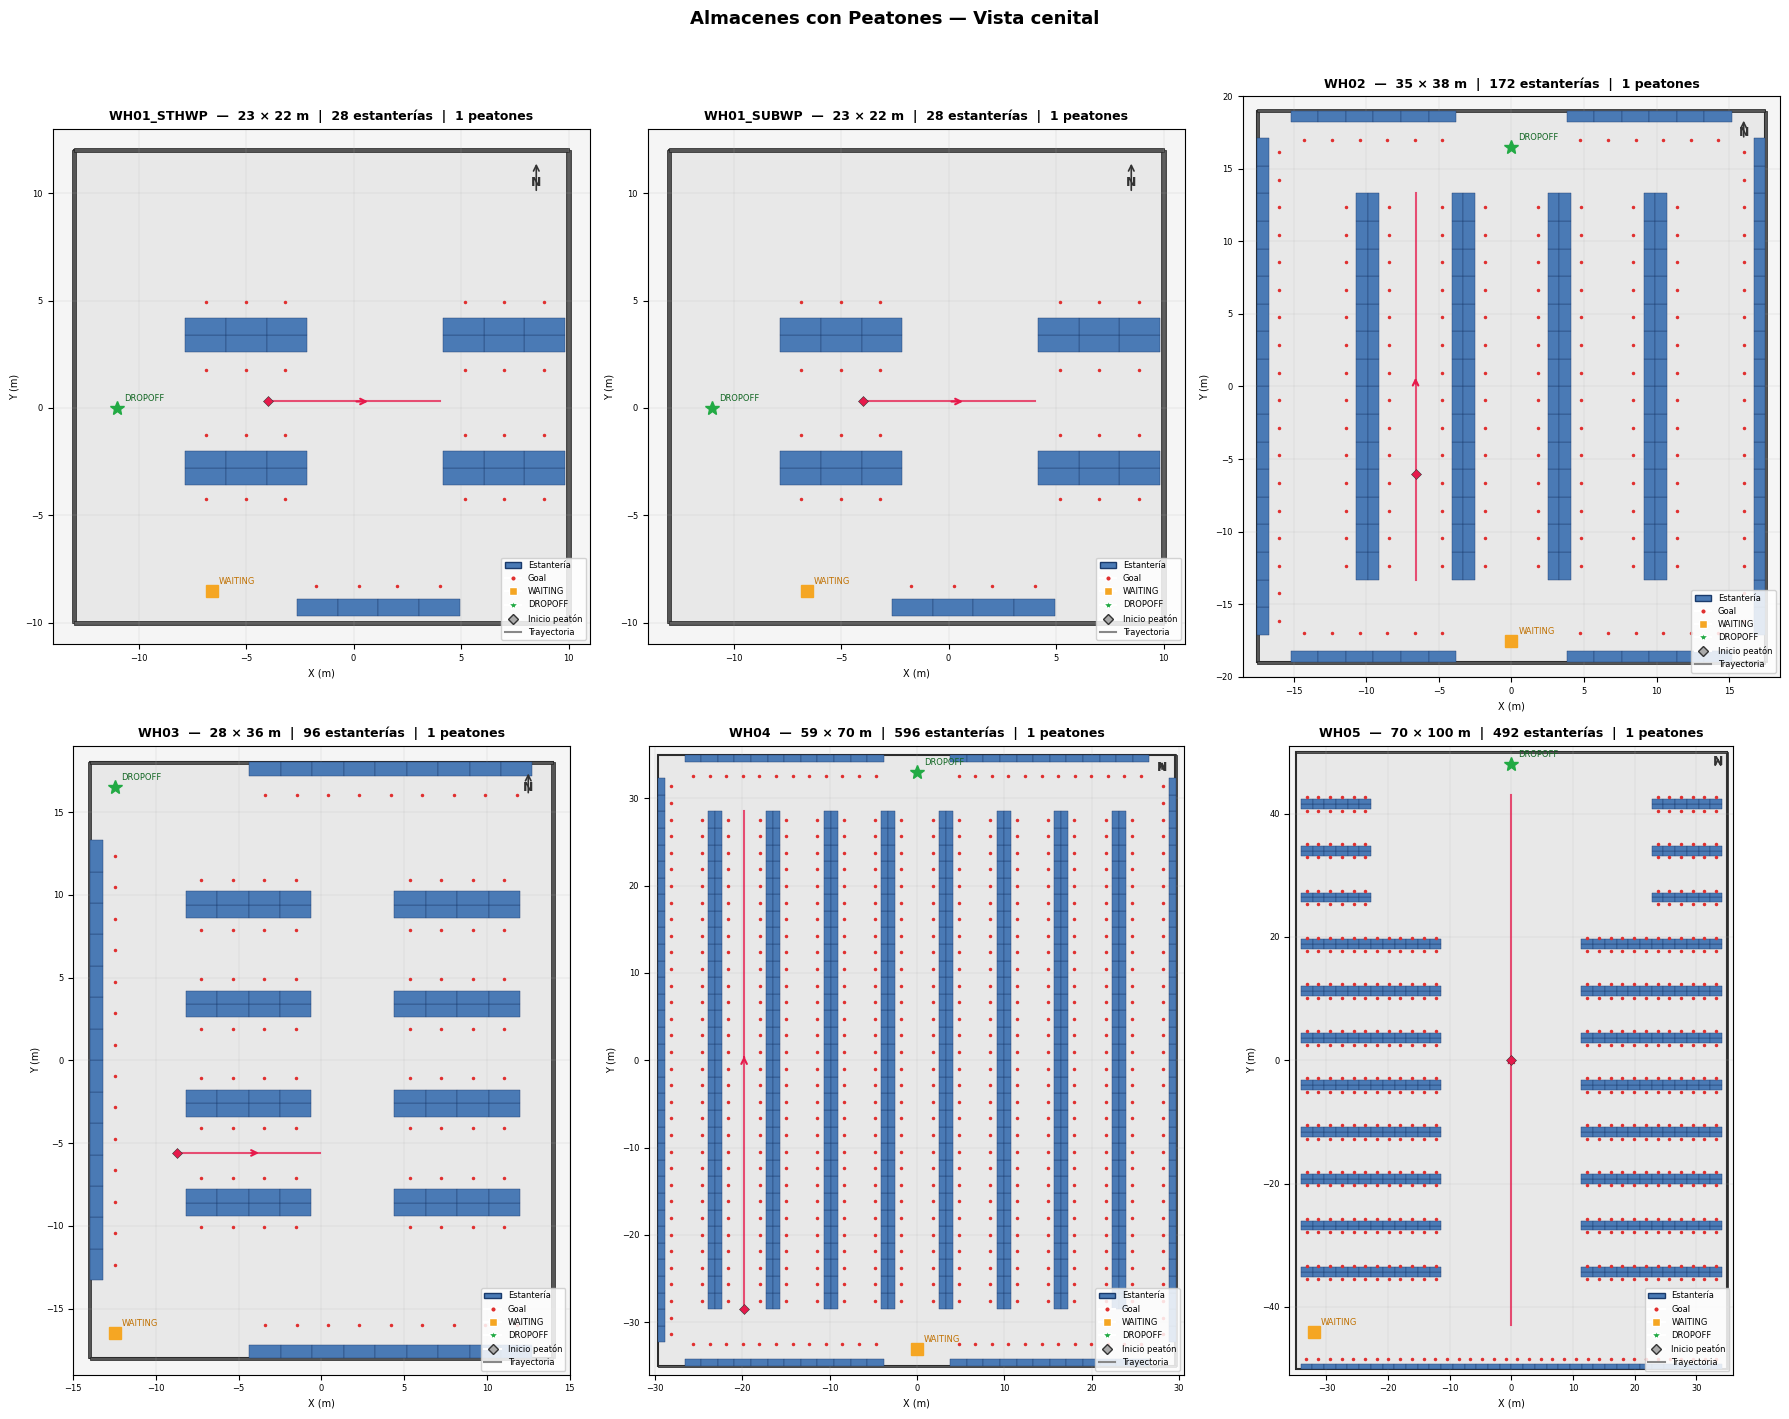

  → imagenes/todos_los_almacenes_ped.png


In [4]:
n = len(entries)   # 6 en total (2 variantes WH01 + WH02–05)
ncols = 3
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 7))
axes = axes.flatten()

for idx, e in enumerate(entries):
    plot_warehouse_ped(e['label'], e['data'], e['ped_list'], axes[idx])

for ax in axes[n:]:
    ax.set_visible(False)

plt.suptitle('Almacenes con Peatones — Vista cenital', fontsize=13,
             fontweight='bold', y=1.01)
plt.tight_layout()
out_path = OUT_DIR / 'todos_los_almacenes_ped.png'
fig.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'  → {out_path}')